In [10]:
import numpy as np
import pandas as pd


In [11]:
df = pd.read_csv("/content/placement.csv")

In [12]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [13]:
df.shape

(100, 4)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [15]:
df = df.iloc[:,1:]

In [16]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [17]:
import matplotlib.pyplot as plt

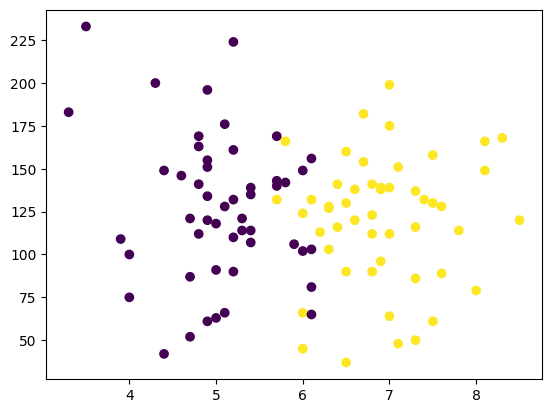

In [18]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [19]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [20]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [21]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [22]:
x.shape

(100, 2)

In [23]:
y.shape

(100,)

#Train test split

In [25]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [26]:
x_train

,cgpa,iq
79,6.5,90.0
11,6.9,138.0
39,4.6,146.0
48,6.6,138.0
63,6.3,128.0
...,...,...
89,4.9,151.0
62,6.0,102.0
71,6.1,132.0
0,6.8,123.0


In [27]:
y_train

,placement
79,1
11,1
39,0
48,1
63,1
...,...
89,0
62,0
71,1
0,1


# scales the values

In [29]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [31]:
x_train = scaler.fit_transform(x_train)

In [32]:
x_train

array([[ 0.40977713, -0.89630257],
       [ 0.75852362,  0.37012999],
       [-1.24676871,  0.58120208],
       [ 0.49696375,  0.37012999],
       [ 0.23540388,  0.10628988],
       [ 1.10727012, -1.00183861],
       [ 1.28164336,  0.1590579 ],
       [-1.07239547, -0.31585431],
       [ 0.75852362, -0.7379985 ],
       [-0.8108356 ,  0.10628988],
       [-0.28771586,  1.18803435],
       [-0.72364897,  0.21182592],
       [-0.28771586,  0.21182592],
       [-0.8108356 , -1.52951885],
       [ 0.84571025,  1.9795547 ],
       [-0.89802222, -0.86991856],
       [-0.54927573,  0.396514  ],
       [-0.20052923,  1.10888232],
       [ 1.71757648, -1.18652669],
       [ 1.19445674,  0.21182592],
       [ 0.49696375, -0.10478222],
       [-0.98520884, -1.6614389 ],
       [-1.07239547,  1.02973028],
       [-0.89802222, -0.15755024],
       [-2.20582157,  2.8766111 ],
       [ 0.58415038,  0.79227418],
       [ 0.40977713,  0.95057825],
       [-0.28771586,  0.50205005],
       [-0.20052923,

In [33]:
x_test = scaler.transform(x_test)

In [34]:
x_test

array([[-2.61559870e-02,  7.53828904e-04],
       [-2.61559870e-02,  6.60354120e-01],
       [-1.50832858e+00,  2.00593871e+00],
       [-1.13342610e-01, -4.74158381e-01],
       [ 3.22590506e-01, -2.10318264e-01],
       [-1.07239547e+00,  4.49282027e-01],
       [ 9.32896869e-01, -2.00443106e+00],
       [-2.61559870e-02, -1.52951885e+00],
       [ 1.80476310e+00,  6.60354120e-01],
       [-9.85208843e-01,  2.64593945e-01],
       [-5.49275726e-01,  2.90977957e-01],
       [-1.42114196e+00, -2.16273513e+00],
       [ 6.10306363e-02, -1.55590286e+00],
       [ 8.45710245e-01,  1.34633842e+00],
       [-7.23648973e-01,  2.63915499e+00],
       [ 1.36882998e+00, -9.22686578e-01],
       [ 1.36882998e+00,  1.06289875e-01],
       [ 6.10306363e-02, -5.53310415e-01],
       [ 6.71336999e-01, -8.96302567e-01],
       [-6.36462350e-01, -2.63086287e-01],
       [ 6.10306363e-02, -1.13375867e+00],
       [-7.23648973e-01, -8.96302567e-01],
       [ 1.54320323e+00, -2.63086287e-01],
       [ 3.

# Train the model


In [36]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

In [38]:
clf.fit(x_train,y_train)

LogisticRegression()

# Evalute the model


In [41]:
y_pred = clf.predict(x_test)

In [42]:
y_test

,placement
27,1
33,0
95,0
1,0
13,1
51,0
5,1
45,1
37,1
40,0


In [43]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.8333333333333334

In [44]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

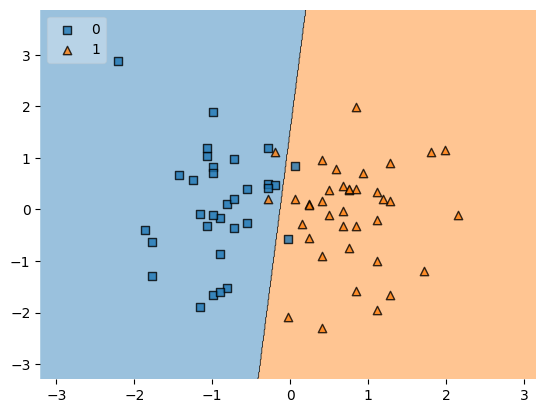

In [45]:
plot_decision_regions(x_train,y_train.values, clf=clf, legend=2)

#deployment the model

In [46]:
import pickle

In [47]:
pickle.dump(clf,open('model.pkl','wb'))